In [1]:
import rasterio as rio
import rioxarray as rxr
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import glob
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from shapely.geometry import box
from subprocess import Popen

In [2]:
planet_path = '/projectnb/modislc/users/seamorez/HLS_FCover/PLSP/rawImage/PSScene/'
main_path = '/projectnb/modislc/users/sjstone/above/data/'

In [3]:
NDVIaug19 = rio.open(main_path + 'ndvi/20230819_200348_13_2465_3B_AnalyticMS_SR_8b_harmonized_clip_NDVI.tif')

In [4]:
NDVIaug19read = NDVIaug19.read(1)

In [ ]:
NDVIaug19read.shape

In [5]:
julyImg = rio.open(main_path + 'planet_clip/20230704_204446_10_2461_3B_AnalyticMS_SR_8b_harmonized_clip_0819clip.tif').read([4,6,8])
aug6Img = rio.open(main_path + 'planet_clip/20230806_200620_72_2440_3B_AnalyticMS_SR_8b_harmonized_clip_0819clip.tif').read([4,6,8])
aug19Img = rio.open(planet_path + '20230819_200348_13_2465_3B_AnalyticMS_SR_8b_harmonized_clip.tif').read([4,6,8])

In [8]:
julyImg

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]]], dtype=uint16)

In [7]:
rio.open(main_path + 'pca/20230704RNIR_20230819RNIR_NA_PCA.tif').read().dtype.name

'float64'

In [ ]:
julyImg[:,aug19Img[0,:,:] == 0] = 0
aug6Img[:,aug19Img[0,:,:] == 0] = 0
aug19Img[:,aug19Img[0,:,:] == 0] = 0

# julyImg[:,np.isnan(aug6Img[0,:,:])] = 0
# aug6Img[:,np.isnan(aug6Img[0,:,:])] = 0
# aug19Img[:,np.isnan(aug6Img[0,:,:])] = 0

In [ ]:
aug19Img[0,:,:] == 0

In [ ]:
plt.imshow(julyImg[0,:,:])

In [ ]:
julyImg[:,np.isnan(aug19Img[0,:,:])] = 0

In [ ]:
julyImg.shape

In [ ]:
aug6Img.shape

In [ ]:
singleImgRead = np.concatenate([julyImg, aug6Img, aug19Img])

# x_size = singleImg.width
# y_size = singleImg.height

# flattenedBands = []

# for lyr in list(range(0,singleImgRead.shape[0])):
# #     singleBandFlat = list(singleImgRead[lyr, 3000:4500, 3000:4200].flatten())
#     singleBandFlat = list(singleImgRead[lyr, :, :].flatten())
#     flattenedBands.append(singleBandFlat)

In [ ]:
singleImgRead.shape

In [ ]:
# singleImgRead

In [ ]:
NDVIjuly = rio.open(main_path + 'ndvi/20230704_204446_10_2461_3B_AnalyticMS_SR_8b_harmonized_clip_NDVI_0819clip.tif').read(1)
NDVIaug6 = rio.open(main_path + 'ndvi/20230806_200620_72_2440_3B_AnalyticMS_SR_8b_harmonized_clip_NDVI_0819clip.tif').read(1)
NDVIaug19 = rio.open(main_path + 'ndvi/20230819_200348_13_2465_3B_AnalyticMS_SR_8b_harmonized_clip_NDVI.tif').read(1)
# NDVIsept = rio.open(main_path + 'ndvi/20230920_204907_94_2473_3B_AnalyticMS_SR_8b_harmonized_clip_NDVI.tif')

# masking out locations that are NA in the the august 19th image
NDVIjuly[np.isnan(NDVIaug19)] = 0
NDVIaug6[np.isnan(NDVIaug19)] = 0
NDVIaug19[np.isnan(NDVIaug19)] = 0

NDVIjuly[np.isnan(NDVIaug6)] = 0
NDVIaug6[np.isnan(NDVIaug6)] = 0
NDVIaug19[np.isnan(NDVIaug6)] = 0

In [9]:
NDVIaug19 = rio.open(main_path + 'ndvi/20230819_200348_13_2465_3B_AnalyticMS_SR_8b_harmonized_clip_NDVI.tif')

In [10]:
bounds = NDVIaug19.bounds

In [11]:
geom = box(*bounds)

In [12]:
bounds

BoundingBox(left=566517.0, bottom=7711941.0, right=584802.0, top=7724937.0)

In [ ]:
# NDVIjuly = rio.open(main_path + 'planet_clip/20230704_204446_10_2461_3B_AnalyticMS_SR_8b_harmonized_clip_0819clip.tif').read([4,6,8])
# NDVIaug = rio.open(main_path + 'ndvi/20230806_200620_72_2440_3B_AnalyticMS_SR_8b_harmonized_clip_NDVI.tif').read(1)
# NDVIsept = rio.open(main_path + 'ndvi/20230920_204907_94_2473_3B_AnalyticMS_SR_8b_harmonized_clip_NDVI.tif').read()

In [ ]:
NDVIjuly[:,np.isnan(NDVIaug19)] = 0

In [ ]:
np.sum(np.isnan(NDVIjuly[0,:,:]))

In [ ]:
image_path[3]

In [ ]:
stackTest = np.stack([NDVIjuly[0,:,:], NDVIaug[0,:,:]])

In [8]:
main_path

'/projectnb/modislc/users/sjstone/above/data/'

In [22]:
# clipping the full rasters to match the extent of the aug 16 raster


command = [
    'gdal_translate',
    '-projwin',
    str(bounds[0]),
    str(bounds[3]),
    str(bounds[2]),
    str(bounds[1]),
    '-of',
    'GTiff',
    main_path + 'dem/Qikiqtaruk_Aspect.tif',
    main_path + 'dem/Qikiqtaruk_Aspect_0819clip.tif'
]
Popen(command).wait()

Input file size is 6662, 5245
0...10...20...30...40...50...60...70...80...90...100 - done.


0

In [36]:
full = rio.open(main_path + 'dem/Qikiqtaruk_Aspect.tif')

In [37]:
full.crs

CRS.from_epsg(32607)

In [38]:
NDVIaug19.crs

CRS.from_epsg(32607)

In [63]:
clipped = rio.open(main_path + 'dem/Qikiqtaruk_Aspect_0819clip.tif')

In [64]:
slopeCheck = clipped.read(1)

In [65]:
slopeCheck 

array([[-9999.     , -9999.     , -9999.     , ..., -9999.     ,
        -9999.     , -9999.     ],
       [-9999.     , -9999.     , -9999.     , ..., -9999.     ,
        -9999.     , -9999.     ],
       [-9999.     , -9999.     , -9999.     , ..., -9999.     ,
        -9999.     , -9999.     ],
       ...,
       [  274.9278 ,   279.8921 ,   264.50012, ..., -9999.     ,
        -9999.     , -9999.     ],
       [-9999.     , -9999.     , -9999.     , ..., -9999.     ,
        -9999.     , -9999.     ],
       [-9999.     , -9999.     , -9999.     , ..., -9999.     ,
        -9999.     , -9999.     ]], dtype=float32)

In [66]:
-9.9990000e+03

-9999.0

In [67]:
# need to make locations where the planet imagery is NA 0 and where the slope imagery is NA (-9999) NA
slopeCheck[np.isnan(NDVIaug19.read(1))] = 0
slopeCheck[slopeCheck == -9999] = 0

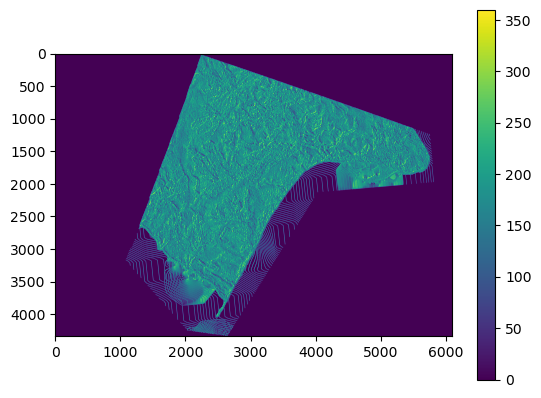

In [68]:
plt.imshow(slopeCheck)
plt.colorbar()

In [20]:
rio.open(image_path[-1]).read(1).shape

(4332, 6095)

In [9]:
NDVIjulyclip = rio.open(main_path + 'ndvi/20230704_204446_10_2461_3B_AnalyticMS_SR_8b_harmonized_clip_NDVI_0816clip.tif').read(1)
NDVIaugclip = rio.open(main_path + 'ndvi/20230806_200620_72_2440_3B_AnalyticMS_SR_8b_harmonized_clip_NDVI_0816clip.tif').read(1)

In [ ]:
NDVIjulyclip[np.isnan(NDVIaug19read)] = 0

In [ ]:
plt.imshow(NDVIjulyclip)

In [ ]:
np.where(NDVIjuly[0,:,:]==np.nan, 0, NDVIjuly[0,:,:])

In [4]:
image_path = glob.glob(planet_path + '*harmonized*.tif')

In [12]:
image_path

['/projectnb/modislc/users/seamorez/HLS_FCover/PLSP/rawImage/PSScene/20230806_200620_72_2440_3B_AnalyticMS_SR_8b_harmonized_clip.tif',
 '/projectnb/modislc/users/seamorez/HLS_FCover/PLSP/rawImage/PSScene/20230929_205227_46_2486_3B_AnalyticMS_SR_8b_harmonized_clip.tif',
 '/projectnb/modislc/users/seamorez/HLS_FCover/PLSP/rawImage/PSScene/20230729_204129_67_2478_3B_AnalyticMS_SR_8b_harmonized_clip.tif',
 '/projectnb/modislc/users/seamorez/HLS_FCover/PLSP/rawImage/PSScene/20230920_204907_94_2473_3B_AnalyticMS_SR_8b_harmonized_clip.tif',
 '/projectnb/modislc/users/seamorez/HLS_FCover/PLSP/rawImage/PSScene/20230704_204446_10_2461_3B_AnalyticMS_SR_8b_harmonized_clip.tif',
 '/projectnb/modislc/users/seamorez/HLS_FCover/PLSP/rawImage/PSScene/20230819_200348_13_2465_3B_AnalyticMS_SR_8b_harmonized_clip.tif']

In [10]:
pcaCheck = rio.open(main_path + 'pca/20230704RNIR_20230806RNIR_PCA.tif')

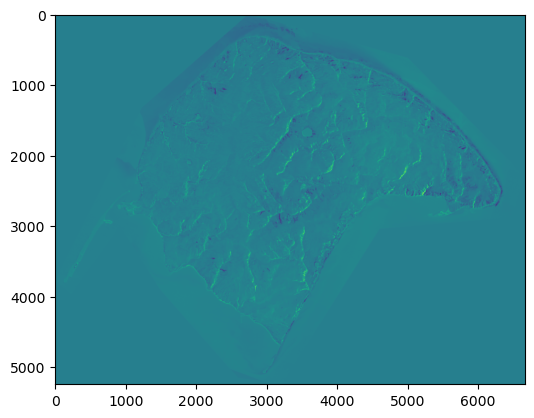

In [11]:
plt.imshow(pcaCheck.read(4))

In [7]:
print(rio.open(image_path[0]).read(1).shape)

(5245, 6662)


In [8]:
print(rio.open(image_path[-2]).read(1).shape)

(5245, 6662)


In [ ]:
len(image_path)

In [ ]:
imgName = image_path[0].split('/')[9][:-4]

In [ ]:
imgName

In [11]:
singleImg = rio.open(image_path[0])
print(singleImg.descriptions)
# singleImgRead = singleImg.read()

('coastal_blue', 'blue', 'green_i', 'green', 'yellow', 'red', 'rededge', 'nir')


In [ ]:
singleImg.nodata

In [15]:
mask = singleImg.read_masks(1)

In [13]:
singleImgRead = singleImg.read([2,3,4,5,6,7,8])

In [ ]:
singleImgRead.shape

In [30]:
maskedBands = []
for bnd in list(range(0, singleImgRead.shape[0])):
    updated = np.where(mask == 0, 0, singleImgRead[bnd, :, :])
    maskedBands.append(updated)

In [31]:
singleImgRead = np.stack(maskedBands)

In [ ]:
singleImg.transform

In [20]:
x_size = singleImg.width
y_size = singleImg.height

In [21]:
x_size

6662

In [32]:
singleImgRead[6,:,:].flatten()

array([0., 0., 0., ..., 0., 0., 0.])

In [23]:
singleImgRead.shape

(7, 5245, 6662)

In [33]:
flattenedBands = []

for lyr in list(range(0,singleImgRead.shape[0])):
    singleBandFlat = list(singleImgRead[lyr, 3000:4500, 3000:4200].flatten())
#     singleBandFlat = list(singleImgRead[lyr, :, :].flatten())
    flattenedBands.append(singleBandFlat)

In [25]:
singleImgRead[1, 3000:4500, 3000:4200].shape

(1500, 1200)

In [34]:
testDF = pd.DataFrame(flattenedBands).T

In [ ]:
testDF

In [35]:
testDF = StandardScaler().fit_transform(testDF)

In [ ]:
testDF.shape

In [36]:
pca = PCA(n_components = 4)
principalComponents = pca.fit_transform(testDF)

In [37]:
pca.explained_variance_ratio_

array([0.87111223, 0.11564795, 0.01003766, 0.00121721])

In [38]:
pcaDF = pd.DataFrame(principalComponents)

In [39]:
pcList = []

for pcLyr in list(range(0, pcaDF.shape[1])):
    singlePC = np.array(pcaDF.iloc[:,pcLyr]).reshape(1500,1200)
    pcList.append(singlePC)

In [40]:
pcStack = np.stack(pcList)

In [41]:
pcStack.dtype.name

'float64'

In [52]:
pcStackChange = pcStack.astype('float16')

In [58]:
pcStackChange[:,singleImgRead[1, 3000:4500, 3000:4200] == 0] = 0

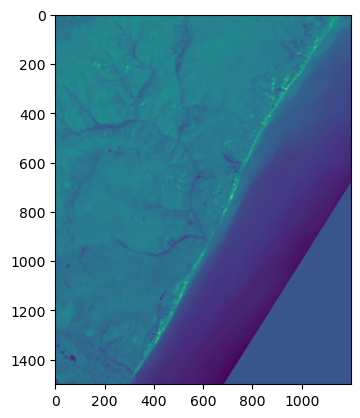

In [60]:
plt.imshow(pcStackChange[0,:,:])

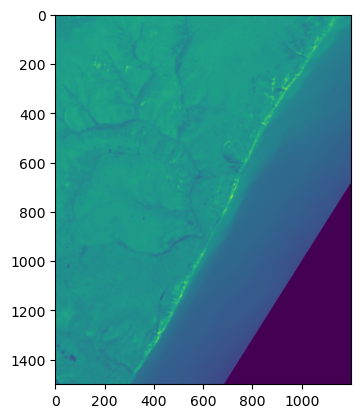

In [42]:
plt.imshow(pcStack[0,:,:])

In [55]:
imgName = 'float16_test'

In [61]:
rio.open(
        main_path + 'pca/' + imgName + '_PCA.tif',
        'w',
        height=pcStack.shape[1],
        width=pcStack.shape[2],
        count=pcStack.shape[0],
        dtype=pcStack.dtype.name,
        crs=singleImg.crs,
        transform=singleImg.transform,
        compress='lzw'
    ).write(pcStackChange)

In [ ]:
(rio.open(main_path + 'pca/' + imgName + '_PCA.tif')).read().shape

In [ ]:
pcaCheck = rio.open(main_path + 'pca/20230729_204129_67_2478_3B_AnalyticMS_SR_8b_harmonized_clip_PCA.tif').read()

In [ ]:
pcaCheck.shape

In [ ]:
plt.imshow(pcaCheck[0,:,:])

EVI calculation

In [ ]:
image_path

In [ ]:
for file in image_path:
    fileName = file.split('/')[9][:-4]
    imgOpen = rio.open(file)
    imgReadIn = imgOpen.read()
    
    mask = imgOpen.read_masks(1)
    
    redBand = np.where(mask == 0, np.nan, imgReadIn[5,:,:])
    nirBand = np.where(mask == 0, np.nan, imgReadIn[7,:,:])
    
    NDVI = (nirBand - redBand) / (nirBand + redBand)
    
    rio.open(
        main_path + 'ndvi/' + fileName + '_NDVI.tif',
        'w',
        height=NDVI.shape[0],
        width=NDVI.shape[1],
        count=1,
        dtype=NDVI.dtype.name,
        crs=imgOpen.crs,
        transform=imgOpen.transform,
        compress='lzw'
    ).write(NDVI, 1)

In [ ]:
for file in image_path:
    fileName = file.split('/')[9][:-4]
    imgOpen = rio.open(file)
    imgReadIn = imgOpen.read()
    
    mask = imgOpen.read_masks(1)
    
    redBand = np.where(mask == 0, np.nan, imgReadIn[5,:,:])
    nirBand = np.where(mask == 0, np.nan, imgReadIn[7,:,:])
    
    evi2 = 2.5 * (nirBand - redBand) / (nirBand + redBand + 1)
    
    rio.open(
        main_path + 'ndvi/' + fileName + '_EVI2.tif',
        'w',
        height=evi2.shape[0],
        width=evi2.shape[1],
        count=1,
        dtype=evi2.dtype.name,
        crs=imgOpen.crs,
        transform=imgOpen.transform,
        compress='lzw'
    ).write(evi2, 1)

In [ ]:
check = rio.open(main_path + 'ndvi/20230704_204446_10_2461_3B_AnalyticMS_SR_8b_harmonized_clip_EVI2.tif').read()

In [ ]:
plt.imshow(check[0,:,:])
plt.colorbar()

In [ ]:
# topTest, bottomTest = EVIcalc(redBand, nirBand, blueBand)
EVIfuncTest = EVIcalc(redBand, nirBand, blueBand)

In [ ]:
np.nanmax(EVIfuncTest)

In [ ]:
NDVI = (nirBand - redBand) / (nirBand + redBand)

In [ ]:
NDVI.shape

In [ ]:
plt.imshow(NDVI)
plt.colorbar()

In [ ]:
plt.imshow(EVIfuncTest, vmin=0, vmax=5)
plt.colorbar()

In [ ]:
np.histogram(EVIfuncTest, range = (np.nanmin(EVIfuncTest), np.nanmax(EVIfuncTest)))

In [ ]:
plt.imshow(EVI)

In [ ]:
plt.imshow(imgRead[7,:,:])

In [ ]:
imgRead[7,:,:]

In [80]:
aug19Img = rio.open(planet_path + '20230819_200348_13_2465_3B_AnalyticMS_SR_8b_harmonized_clip.tif').read([6,8])

In [78]:
pcaCheck = rio.open(main_path + 'pca/20230704RNIR_20230819RNIR_slope_aspect_PCA.tif')

In [82]:
pcaRead = pcaCheck.read()

In [85]:
pcaRead[:, aug19Img[0,:,:] == 0] = np.nan

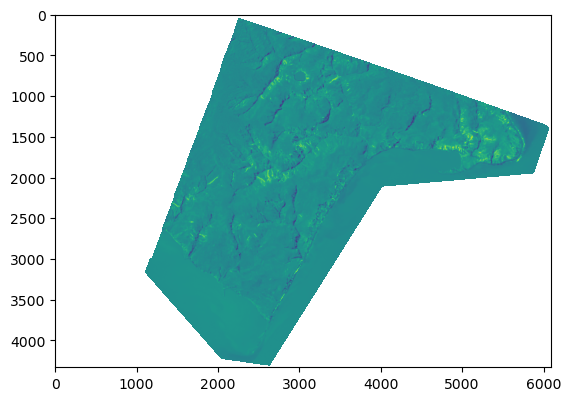

In [90]:
plt.imshow(pcaRead[5,:,:])

In [94]:
rio.open(
        main_path + 'pca/20230704RNIR_20230819RNIR_slope_aspect_PCA_NAmask_band6.tif',
        'w',
        height=pcaRead.shape[1],
        width=pcaRead.shape[2],
        count=1,
        dtype=pcaRead.dtype.name,
        crs=pcaCheck.crs,
        transform=pcaCheck.transform,
        compress='lzw'
    ).write(pcaRead[5:,:,:])

In [93]:
pcaRead[5:,:,:].shape

(1, 4332, 6095)